In [ ]:

#cartopy data directory structure
#src = "/path/to/CARTOPY_DATA_DIR"+"/shapefiles/natural_earth/physical/"


#shutil.copytree(src, dst)

'/content/drive/MyDrive/cartopy_shapefiles/cartopy/lakes'

In [1]:
import os
from torch.utils.data import Dataset, DataLoader

import numpy as np
import sys
import torch.nn as nn
import matplotlib.pyplot as plt
os.environ["CARTOPY_DATA_DIR"] = "/leonardo_work/ICT25_ESP/sdigioia/CORDEX-ML/cartopy/"

import pickle


import matplotlib

sys.path.append("/leonardo_work/ICT25_ESP/sdigioia/CORDEX-ML/GNN4CD-CORDEXML")
from utils.plots import extremes_cmap
from utils.tools import date_to_idxs_new

import matplotlib.ticker as ticker
import matplotlib.colors as colors
import matplotlib.patches as patches
# import colorcet as cc

import warnings
warnings.filterwarnings("ignore")

from matplotlib.ticker import ScalarFormatter, NullFormatter
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

In [2]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature



import sys
#sys.path.append('evaluation')
#import indices, diagnostics

In [3]:
DOMAIN="ALPS"
EXPERIMENT="ESD_pseudo_reality"

In [4]:
input_path=f"/leonardo_work/ICT25_ESP/sdigioia/CORDEX-ML/CORDEX-graphs/{DOMAIN}_domain/{EXPERIMENT}/"
output_path=f"/leonardo_work/ICT25_ESP/sdigioia/CORDEX-ML/Emulator_output/{DOMAIN}_domain/{EXPERIMENT}/predictions/mse_20/"

In [5]:
target_file="target.pkl"
output_file=f"validation_precipitation_epoch_20.pkl"
output_season_file=f"validation_seasonal_precipitation_epoch_20.pkl"

In [25]:
with open(output_path+output_file, 'rb') as f2:
        graph = pickle.load(f2)

In [6]:
# Load the original target
#with open(args.input_path+args.target_file, 'rb') as f:
#        pr_target = pickle.load(f)

# Load the seasonal prediction file
with open(output_path+output_season_file, 'rb') as f1:
        results_season = pickle.load(f1)



In [7]:
lon_high = results_season["lon"]
lat_high = results_season["lat"]
times = results_season["times"]
pr_target = results_season["pr_original"]
pr_pred = results_season["pr_gnn4cd"]
pr_pred_seasons = results_season["pr_gnn4cd_seasons"]
pr_target_seasons = results_season["pr_original_seasons"]

In [26]:

graph_lat_high= graph["high"].lat 
graph_lon_high= graph["high"].lon 
high_nodes_degree =graph["high"].degree 

In [8]:
pr_pred[0:10]

array([[0.7149876 , 0.7149876 , 0.7149876 , ..., 0.7149876 , 0.7149876 ,
        0.7149876 ],
       [0.5902626 , 0.5902626 , 0.5902626 , ..., 0.5902626 , 0.5902626 ,
        0.5902626 ],
       [0.75975686, 0.75975686, 0.75975686, ..., 0.75975686, 0.75975686,
        0.75975686],
       ...,
       [0.8001753 , 0.8001753 , 0.8001753 , ..., 0.8001753 , 0.8001753 ,
        0.8001753 ],
       [0.5431618 , 0.5431618 , 0.5431618 , ..., 0.5431618 , 0.5431618 ,
        0.5431618 ],
       [0.7104855 , 0.7104855 , 0.7104855 , ..., 0.7104855 , 0.7104855 ,
        0.7104855 ]], dtype=float32)

In [28]:
pos = np.concatenate((np.expand_dims(graph['high'].lon,-1), np.expand_dims(graph['high'].lat,-1)), axis=-1)
pos.shape

(13830, 2)

In [29]:
lon = pos[:,0]
lat = pos[:,1]

In [36]:
lon

array([ 2.15189305,  2.28765715,  2.4234748 , ..., 21.52919018,
       21.70170823, 21.87410804])

In [11]:
pr_target_seasons[0].shape

(13830, 88)

In [13]:
domain=DOMAIN

In [21]:
mean_pr_target= np.mean(pr_target, axis=1)

In [22]:
mean_pr_target.shape

(13830,)

In [32]:
def plot_data_map_new(data, lon, lat, var_name, domain,vmin, vmax, plot_path="/leonardo_work/ICT25_ESP/sdigioia/CORDEX-ML/GNN4CD-CORDEXML/plots/",
                  fig_title='Precipitation map',  figsize=(8,8), cmap='viridis'):

    if domain == 'NZ':
        central_longitude = 180
    else :
        central_longitude = 0 

    plt.figure(figsize=figsize)
    ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=central_longitude))

    if (domain == 'NZ') or (domain == 'SA'):
        cs = ax.pcolormesh(lon, lat,
                           data,
                           transform=ccrs.PlateCarree(),
                           vmin=vmin, vmax=vmax,
                           cmap=cmap)
        
    elif domain == 'ALPS':
        cs = ax.scatter(lon, lat,
                           data,
                           vmin=vmin, vmax=vmax,
                           cmap=cmap)

    ax.coastlines(resolution='10m')
    ax.add_feature(cfeature.LAKES.with_scale("10m"))
    entire_fig_title=fig_title+f' ({var_name})'
    plt.title(entire_fig_title)
    filename=f'{plot_path}/plot_{var_name}_{domain}_domain.pdf'
    plt.savefig(filename)
    #plt.show()




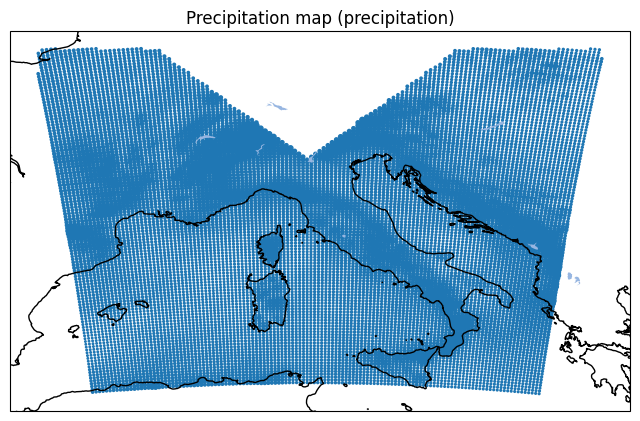

In [33]:
plot_data_map_new(mean_pr_target, lon_high, lat_high, "precipitation", domain,np.min(pr_target), np.max(pr_target), plot_path="/leonardo_work/ICT25_ESP/sdigioia/CORDEX-ML/GNN4CD-CORDEXML/plots/",
                  fig_title='Precipitation map',  figsize=(8,8), cmap='viridis')

In [ ]:
def plot_psd(psd_target, psd_pred, domain, plot_path):
    plt.loglog(psd_target.wavenumber, psd_target, label="Target")
    plt.loglog(psd_pred.wavenumber, psd_pred, label="Prediction")
    plt.xlabel("Wavenumber")
    plt.title("Power Spectral Density")
    plt.legend()
    filename=f'{plot_path}/PSD_plot_{domain}_domain.pdf'
    plt.savefig(filename)
    #plt.show()

In [ ]:
#

In [31]:
def plot_data_map_new(data, lon, lat, var_name, domain,vmin, vmax, plot_path,
                  fig_title='Plot of variable',  figsize=(8,8), cmap='viridis'):

    central_longitude = 180 if domain == 'NZ' else 0 if domain == 'ALPS'

    plt.figure(figsize=figsize)
    ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=central_longitude))

    if (domain == 'NZ') or (domain == 'SA'):
        data[var_name].plot(ax=ax, transform=ccrs.PlateCarree(),
                            vmin=vmin, vmax=vmax,
                            cmap=cmap)
    elif domain == 'ALPS':
        cs = ax.scatter(lon, lat,
                           data,
                           vmin=vmin, vmax=vmax,
                           cmap=cmap)

    ax.coastlines(resolution='10m')
    ax.add_feature(cfeature.LAKES.with_scale("10m"))
    entire_fig_title=fig_title+f' ({var_name})'
    plt.title(entire_fig_title)
    filename=f'{plot_path}/plot_{var_name}_{domain}_domain.pdf'
    plt.savefig(filename)
    #plt.show()





SyntaxError: non-default argument follows default argument (4089865804.py, line 2)

In [ ]:
def plot_maps_new(lon,lat, pr_pred, pr, save_path, save_file_name,
        x_size, y_size, font_size_title, font_size=80, pr_min=0, pr_max=2500, aggr=np.nanmean, title="", domain,
        cmap='jet', legend_title="pr", xlim=None, ylim=None, cbar_y=1, cmap_type=None,
        cbar_title_size=80, cbar_pad=0, subtitle_y=1, subtitle_x=0.45, s=150, show_ticks=True, num=16, bounds=None, norm=None):

    plt.rcParams.update({'font.size': int(font_size)})

    central_longitude = 180 if domain == 'NZ' else 0 if domain == 'ALPS'
    proj = ccrs.PlateCarree(central_longitude=central_longitude)


    fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(x_size*2,y_size),subplot_kw={"projection": proj})


    # Define cmaps
    if cmap_type is None:
        pr_min = pr_min if pr_min is not None else np.nanmin(np.nanmin(pr_pred), np.nanmin(pr))
        pr_max = pr_max if pr_max is not None else np.nanmax(np.nanmax(pr_pred), np.nanmax(pr))

    if cmap_type == "custom_blue_discrete_avg":
        c_list = ["#F8FBFE",
                  "#E1EBF6",
                  "#CADBED",
                  "#A7C9DE",
                  "#7AADD2",
                  "#5691C1",
                  "#3771B0",
                  "#205297",
                  "#123167"]

        cmap = matplotlib.colors.ListedColormap(c_list, name='cmap_blue', N=len(c_list)) # N=cmap.shape[0])

        # Bounds may be unevenly spaced:
        bounds = np.array([0.0, 0.1, 1.0, 2.5, 5.0, 7.5, 10.0, 15.0, 20.0, 30.0])
        norm = colors.BoundaryNorm(boundaries=bounds, ncolors=len(c_list))
    elif cmap_type == "custom_jet_discrete_avg":
        bounds = np.array([0.0, 0.1, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 7.5, 10.0, 12.5, 15.0])
        norm = colors.BoundaryNorm(boundaries=bounds, ncolors=256)
    elif cmap_type == "custom_jet_discrete_avg_limits":
        bounds = bounds
        # bounds = np.linspace(pr_min, pr_max, num)
        norm = colors.BoundaryNorm(boundaries=bounds, ncolors=256)
    elif cmap_type == "custom_bwr_discrete_avg":
        bounds = np.array([-100,-50,-25,-10,-5,5,10,50,100,150])
        norm = colors.BoundaryNorm(boundaries=bounds, ncolors=256)

    v_s = []
    if aggr is not None:
        v_s.append(aggr(pr_pred, axis=1))
        v_s.append(aggr(pr, axis=1))
    else:
        v_s.append(pr_pred)
        v_s.append(pr)

    sub_titles = ["GNN4CD R-all", "ALADIN"]

    for idx in range(2):
        #if cmap_type is not None or norm is not None:
        #    im = ax[idx].scatter(lon,lat,c=v_s[idx], marker="s", s=s, cmap=cmap, norm=norm)
        #else:
        #    im = ax[idx].scatter(lon,lat,c=v_s[idx], marker="s", s=s, cmap=cmap, vmin=pr_min, vmax=pr_max)
        im = ax[idx].pcolormesh(lon, lat,v_s[idx],transform=ccrs.PlateCarree(), vmin=pr_min, vmax=pr_max,cmap='viridis')

        # im = ax[idx].scatter(lon,lat,c=v_s[idx], marker="s", s=s, vmin=pr_min, vmax=pr_max, cmap=cmap)
        ax[idx].coastlines(resolution='10m')
        ax[idx].set_xlim([lon.min()-0.25,lon.max()+0.25])
        ax[idx].set_ylim([lat.min()-0.25,lat.max()+0.25])
        ax[idx].set_title(sub_titles[idx])
        if xlim is not None:
            ax[idx].set_xlim(xlim)
        if ylim is not None:
            ax[idx].set_ylim(ylim)
        if not show_ticks:
            ax[idx].xaxis.set_major_locator(ticker.NullLocator())
            ax[idx].yaxis.set_major_locator(ticker.NullLocator())
    ax[1].yaxis.set_major_locator(ticker.NullLocator())

    # cbar_ax = fig.add_axes([0.95,0.1, 0.01, 0.8])
    cbar_ax = fig.add_axes([0.95, 0.15, 0.02, 0.7])
    cbar = fig.colorbar(im, cax=cbar_ax, aspect=25, pad=cbar_pad)
    cbar.ax.set_title(legend_title, rotation=0, fontsize=cbar_title_size, pad=80)
    _ = fig.suptitle(title, fontsize=font_size_title, x=subtitle_x, y=subtitle_y)

    plt.subplots_adjust(wspace=0, hspace=0)
    plt.savefig(f'{save_path}{save_file_name}', dpi=400, bbox_inches='tight', pad_inches=0.0)

In [ ]:
lon_min = np.min(lon_high)
lon_max = np.max(lon_high)
lat_min =np.min(lat_high)
lat_max =np.max(lat_high)

day_start=1
month_start=1
year_start=1975
day_end=31
month_end=12
year_end=1975

x_size = 38
y_size = 44
xlim = [lon_min, lon_max ]
ylim = [lat_min, lat_max]
font_size = 100
font_size_title = 120
cbar_y = 0.95
cbar_title_size = 100

In [ ]:
# Combined average
plot_maps_new(pos, pr, pr_target, pr_min=0, aggr=np.nanmean, pr_max=0.5, s=40,
    title=f"Average", legend_title="[mm/day]", cmap=cmap_pr, norm=norm_avg, save_path="/leonardo_work/ICT25_ESP/sdigioia/CORDEX-ML/plots/", save_file_name="average_pr_map.pdf",
    x_size=x_size, y_size=y_size, font_size_title=font_size_title, font_size=font_size, cbar_title_size=cbar_title_size,
    ylim=ylim, xlim=xlim, cbar_y=cbar_y, subtitle_x=0.55)

plt.savefig(f'./Rall_avg.png', bbox_inches='tight', pad_inches=0.0)

In [ ]:
def plot_seasonal_maps(pos, pr, pr_min, pr_max, aggr=np.mean, title="", cmap='jet', unit="[mm/day]", norm=None, s=10, domain="ALPS"):


    plt.rcParams.update({'font.size': 70})
    central_longitude = 180 if domain == 'NZ' else 0 if domain == 'ALPS'
    proj = ccrs.PlateCarree(central_longitude=central_longitude)
    fig, ax = plt.subplots(nrows=1, ncols=4, figsize=(100,24), subplot_kw={"projection": proj})
    ax_list = [ax[0], ax[1], ax[2], ax[3]]
    text_list = ['DJF', 'MAM', 'JJA', 'SON']

    lon = pos[:,0]
    lat = pos[:,1]

    for season in range(4):
        axi = ax_list[season]
        v = pr[season]
        if aggr is not None:
            v_s = aggr(v, axis=1)
        else:
            v_s = v


        im = axi.pcolormesh(lon, lat,v_s,transform=ccrs.PlateCarree(), vmin=pr_min, vmax=pr_max,cmap='viridis')
        axi.coastlines(resolution='10m')
        axi.add_feature(cfeature.LAKES.with_scale("10m"))

        # axi.text(0.95, 0.9, text_list[s], transform=axi.transAxes,  horizontalalignment='right',fontsize=70, family='sans-serif')
        axi.set_title(text_list[season])


        axi.set_xlim([6.75, 18.50])
        axi.set_ylim([36.50, 47.00])

        if season>0:
            # axi.yaxis.set_major_locator(ticker.NullLocator())
            axi.yaxis.set_major_formatter(NullFormatter())
            for tick in axi.yaxis.get_major_ticks():
                tick.tick1line.set_visible(False)
                tick.tick2line.set_visible(False)
                tick.label1.set_visible(False)
                tick.label2.set_visible(False)

    plt.subplots_adjust(wspace=0, hspace=0)

    cbar = fig.colorbar(im, ax=ax, aspect=25, pad=0.025)
    cbar.ax.set_title(unit, rotation=0, fontsize=70, pad=80)

    _ = fig.suptitle(title, fontsize=70, x=0.45, y=1.015)
    # plt.savefig(f'results/cumulative_2015_seasons_predictions.png', dpi=800, bbox_inches='tight', pad_inches=0.0)


In [ ]:
plot_seasonal_maps(pos, avg_bias_seasons, pr_min=-150, pr_max=150, aggr=None, title='Average - bias % (GNN4CD R-all - GRIPHO)', cmap=BrBG_16, unit="[%]", s=150)
plt.savefig(f'./Rall_seasons_avg_bias.png', bbox_inches='tight', pad_inches=0.0)

In [ ]:
plot_single_map(pos, pr_bias_percentage_avg, pr_min=-150, aggr=None, pr_max=150, s=40,
    title=f"Average precipitation percentage bias - Year 2016", legend_title="[%]", subtitle_y=0.98, subtitle_x=0.5,
    cmap=BrBG_16, save_path=None, save_file_name=None, zones=zones, x_size=x_size, y_size=y_size,
    font_size_title=85, font_size=font_size, cbar_title_size=100, ylim=ylim, xlim=xlim, cbar_y=cbar_y)

plt.savefig(f'./Rall_avg_bias.png', bbox_inches='tight', pad_inches=0.0)

In [ ]:
rmse = diagnostics.rmse(x0=y_test, x1=y_pred,
                        var=var_target, dim='time')
print(f'Mean RMSE: {rmse[var_target].mean().values.item()}')

plot_data_map(data=rmse, var_name=var_target, domain=domain, vmin=0, vmax=5,
              fig_title='RMSE', cmap='Reds')